# 04 - Base Learners

**Is the champion a property of the learner, or of the estimator underneath it?**

Notebook 02 built seven uplift learners and picked one. Notebook 03 measured
that pick on a confirmatory sample and reported the number. Both of them, and
every run in `outputs/`, gave six of the seven the same boosted trees and the
seventh, transformed-outcome, ridge - one fixed assignment either way, never
a choice that was varied.

That leaves a gap between what was measured and what gets claimed. An uplift
learner is not a model. It is a *recipe* for turning ordinary supervised
estimators into an effect estimate: the S-learner says "fit one outcome model
with treatment as a feature and subtract", the T-learner says "fit two and
subtract", the DR-learner says "build a doubly robust pseudo-outcome and
regress it". Each recipe needs an estimator to run on, and the project always
handed it the same one.

So "the S-learner wins" has always been shorthand for "the S-learner wins at
that one assignment of estimators". This notebook removes the shorthand.

What this notebook covers:

1. Why the stability experiment cannot answer this
2. A meta-learner is a recipe, and the estimator is a separate choice
3. The three base learner families, and why these three
4. What is deliberately held fixed, and why holding it matters
5. Running the comparison live
6. The full-scale result
7. A determinism wrinkle the forest introduces
8. A cross-check the tables have to pass
9. What this changes, and what it does not

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.criteo import load_criteo, subsample_criteo
from src.experiments.honest_uplift import (
    run_honest_uplift_experiment,
    summarize_selection,
)
from src.models.base import BASE_LEARNER_FAMILIES, resolve_base_family
from src.models.registry import REFERENCE_POLICIES, default_model_factories
from src.models.s_learner import SLearner

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

OUTPUTS = ROOT / "outputs"
AUDIT_SAMPLE = ROOT / "data/processed/criteo_audit_1m.parquet"
print("project root:", ROOT)
print("families available:", ", ".join(BASE_LEARNER_FAMILIES))

project root: D:\code\Vinsmart Future
families available: gradient_boosting, linear, forest


## 1. Why the stability experiment cannot answer this

`outputs/visit_stability.md` repeats the whole protocol ten times. It is a real
robustness check, but it varies exactly one thing: **which rows land in which
split**. The estimator inside every candidate is identical in all ten runs.

That means the two experiments ask different questions, and neither substitutes
for the other:

| Experiment | What varies | What is held fixed | Question |
|---|---|---|---|
| `visit_stability.md` | the data split | the estimator | Would a different split have picked a different learner? |
| this notebook | the estimator | the data split | Would a different estimator have picked a different learner? |

A learner that wins across ten splits and three estimators is on much firmer
ground than one that wins across ten splits alone. A learner that wins across
splits but loses when the estimator changes was never really the winner; the
pairing was.

## 2. A meta-learner is a recipe, and the estimator is a separate choice

The cleanest way to see this is in the code. Here is the entire fitting logic of
the S-learner. Notice that it never names an estimator: it asks a family for
one.

In [2]:
import inspect

print(inspect.getsource(SLearner.fit))

    def fit(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        treatment: pd.Series,
        random_state: int = 42,
    ) -> SLearner:
        if self.model is None:
            self.model = resolve_base_family(self.base_family).classifier(random_state)
        X_fit = self._with_treatment(X, treatment)
        self.model.fit(X_fit, y)
        return self



`resolve_base_family` is the seam. Passing `None` returns boosted trees, which
is what every published result in this repository was produced with, so nothing
about the default path changed when families were introduced.

The two constructors take a seed rather than returning a ready-made estimator.
That matters for the multi-component learners: the X-learner builds four models
and deliberately seeds them differently, so handing it one shared instance would
collapse four independent fits into one.

In [3]:
family = resolve_base_family(None)
print("default family:", family.name)
print()

for name in BASE_LEARNER_FAMILIES:
    current = resolve_base_family(name)
    print(f"{name:>18} classifier: {current.classifier(42)}")
    print(f"{'':>18} regressor : {current.regressor(42)}")
    print()

default family: gradient_boosting



 gradient_boosting classifier: LGBMClassifier(colsample_bytree=0.9, learning_rate=0.05, n_estimators=250,
               n_jobs=-1, random_state=42, subsample=0.9, verbosity=-1)
                   regressor : LGBMRegressor(colsample_bytree=0.9, learning_rate=0.05, n_estimators=250,
              n_jobs=-1, random_state=42, subsample=0.9, verbosity=-1)

            linear classifier: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])
                   regressor : Pipeline(steps=[('standardscaler', StandardScaler()), ('ridge', Ridge())])

            forest classifier: RandomForestClassifier(min_samples_leaf=50, n_estimators=200, n_jobs=-1,
                       random_state=42)
                   regressor : RandomForestRegressor(max_features='sqrt', min_samples_leaf=50,
                      n_estimators=200, n_jobs=-1, random_state=42)



## 3. The three families, and why these three

Three points on a spectrum of how flexible an estimator is, chosen so that a
ranking which survives all three has survived a genuine disagreement about how
to fit a function, not three flavours of the same idea.

| Family | Estimator | Inductive bias |
|---|---|---|
| `gradient_boosting` | LightGBM | many shallow trees, each correcting the last |
| `linear` | scaled logistic regression and ridge | additive in the features, penalised |
| `forest` | bagged deep trees, `sqrt` features per split | independent deep trees, averaged |

Boosting and bagging are both tree methods but disagree about where accuracy
comes from: boosting reduces bias sequentially, a forest reduces variance by
averaging. The linear family is the far end, with the strongest bias and the
least capacity to overfit a noisy target.

There is a detail worth pausing on. The locked configuration was never
*uniformly* boosted trees. The transformed-outcome learner has always used ridge
on purpose, and its docstring gives the reason: at a propensity of 0.85 its
regression target takes only three values, so a flexible learner fits the spikes
and a penalised linear model cannot. Ridge is exactly what the linear family's
regressor is, so that one candidate is unchanged when the comparison moves to
the linear column, and only the other six move.

In [4]:
from src.models.modified_outcome import ModifiedOutcomeModel

print(ModifiedOutcomeModel.__doc__)

Transformed-outcome learner for randomized treatment.

    The transformation appears in Athey and Imbens, *Recursive Partitioning for
    Heterogeneous Causal Effects*, PNAS 113(27):7353-7360.

    The regression target is Y(T-e)/(e(1-e)). In a randomized experiment where
    propensity e is independent of X, the conditional expectation of this target
    is the treatment effect.

    Ridge rather than gradient boosting is deliberate. At e = 0.85 the target
    takes only three values: -6.67 for a responding control, +1.18 for a
    responding treated row, and exactly 0 for the ~95% who do not respond. A
    flexible learner fits those spikes; a linear model constrained by an L2
    penalty cannot.
    


## 4. What is held fixed, and why holding it matters

Two things deliberately do **not** move with the family under test. Both would
have quietly invalidated the comparison.

**The reference policy.** Response targeting stands for what the business
already does. If it were rebuilt on whichever estimator is under test, each
column would be measuring its candidates against a different incumbent, and the
incremental outcomes could not be read across columns at all. Worse, a family
whose estimator happens to suit the response model poorly would make its uplift
candidates look good for the wrong reason.

**The AIPW nuisance models.** These are the measuring instrument: they produce
the outcome predictions that the doubly robust score corrects with. The
estimator under test lives inside the candidates, not inside the scorer. Moving
both at once would confound the thing being measured with the thing measuring
it.

Both are enforced in the registry rather than left to the caller, so a future
run cannot get it wrong by omission.

In [5]:
for name in BASE_LEARNER_FAMILIES:
    factories = default_model_factories(base_family=name)
    response = factories["response_model"]()
    champion_candidate = factories["s_learner"]()
    print(
        f"{name:>18} | response_model.base_family = {response.base_family!s:>18}"
        f" | s_learner.base_family = {champion_candidate.base_family!s:>18}"
    )

print()
print("reference policies, never candidates:", REFERENCE_POLICIES)

 gradient_boosting | response_model.base_family =               None | s_learner.base_family =  gradient_boosting
            linear | response_model.base_family =               None | s_learner.base_family =             linear
            forest | response_model.base_family =               None | s_learner.base_family =             forest

reference policies, never candidates: ('response_model', 'random_targeting')


## 5. Running the comparison live

The tracked run uses the same sample, folds, seed, and budget as the run that
chose the locked champion. That matching is not incidental. An earlier version
of the stability experiment ran its selection stage on eight times less data
than the real one, and the wider intervals that produced looked like an unstable
selection rule. They were not: they were a smaller sample.

To keep this notebook to a few minutes it runs on a slice, which means its
intervals are wider than the tracked run's for exactly that reason. The point of
running it here is to show the machinery working end to end and to confirm the
three families genuinely disagree; the headline is read from the tracked files
in section 6.

In [6]:
NOTEBOOK_ROWS = 150_000
NOTEBOOK_FOLDS = 2
PRIMARY_BUDGET = 0.05
BUDGET_PCT = 100 * PRIMARY_BUDGET
SEED = 777

dataset = load_criteo(AUDIT_SAMPLE, outcome="visit")
dataset = subsample_criteo(dataset, NOTEBOOK_ROWS, SEED)
print(f"{len(dataset.X):,} rows, {dataset.treatment.mean():.1%} treated, "
      f"{dataset.y.mean():.2%} visit rate")

150,000 rows, 85.0% treated, 4.70% visit rate


In [7]:
live_rows = []
live_summary = []

for name in BASE_LEARNER_FAMILIES:
    result = run_honest_uplift_experiment(
        dataset,
        model_factories=default_model_factories(base_family=name),
        budgets=(0.05, 0.10, 0.20, 0.30),
        primary_budget=PRIMARY_BUDGET,
        random_state=SEED,
        selection_folds=NOTEBOOK_FOLDS,
    )
    contrasts = result.validation_contrasts
    uplift_only = [
        policy for policy in result.validation_scores
        if policy not in REFERENCE_POLICIES
    ]
    selected = contrasts[
        np.isclose(contrasts["budget_pct"], BUDGET_PCT)
        & contrasts["policy"].isin(uplift_only)
    ].sort_values("ci_lower", ascending=False).reset_index(drop=True)
    selected.insert(0, "base_family", name)
    selected["selection_rank"] = np.arange(1, len(selected) + 1)
    live_rows.append(selected)
    live_summary.append(
        {
            "base_family": name,
            "champion": result.champion,
            **summarize_selection(result, BUDGET_PCT),
        }
    )
    print(f"{name:>18}: champion {result.champion}")

live = pd.concat(live_rows, ignore_index=True)
live_summary = pd.DataFrame(live_summary)

 gradient_boosting: champion s_learner


            linear: champion t_learner


            forest: champion r_learner


In [8]:
def wide_by_family(table, column, families):
    """Lay one column out as candidates by families.

    Rows are ordered by the first family's rank, so a family that reorders the
    candidates reads as numbers out of sequence rather than as a table the
    reader has to diff by eye.
    """
    indexed = table.set_index(["base_family", "policy"])[column]
    ordered = (
        table[table["base_family"] == families[0]]
        .sort_values("selection_rank")["policy"]
        .tolist()
    )
    return pd.DataFrame(
        {family: indexed.loc[family].reindex(ordered) for family in families},
        index=ordered,
    )


live_families = list(BASE_LEARNER_FAMILIES)
wide_by_family(live, "selection_rank", live_families).astype(int)

,gradient_boosting,linear,forest
s_learner,1,2,6
x_learner,2,4,5
t_learner,3,1,4
dr_learner,4,5,2
r_learner,5,3,1
transformed_outcome,6,6,3
cvt,7,7,7


In [9]:
live_summary[
    [
        "base_family",
        "champion",
        "runner_up",
        "selection_margin",
        "champion_selection_halfwidth",
    ]
].round(1)

,base_family,champion,runner_up,selection_margin,champion_selection_halfwidth
0,gradient_boosting,s_learner,x_learner,78.0,171.6
1,linear,t_learner,s_learner,86.3,168.8
2,forest,r_learner,dr_learner,33.3,159.5


Two things to read off this, both of which the full run repeats at scale.

The ranks are not identical across the columns, and they were never going to be:
the candidates sit inside each other's intervals, so the ordering below the top
is being decided by noise. The question is never "is the order identical" but
"is any reordering larger than the uncertainty in the numbers being ordered".

The `selection_margin` against `champion_selection_halfwidth` is where that gets
answered. The margin is the gap between first and second place; the half-width
is the uncertainty in first place's own estimate. A margin far below the
half-width means the column ranked its candidates without separating them.

## 6. The full-scale result

Read from the tracked run: the full audit sample, the three-fold selection, and
the seed that chose the locked champion.

In [10]:
comparison = pd.read_csv(
    OUTPUTS / "tables/base_learner_comparison.csv", encoding="utf-8-sig"
)
summary = pd.read_csv(
    OUTPUTS / "tables/base_learner_selection_summary.csv", encoding="utf-8-sig"
)
families = list(dict.fromkeys(comparison["base_family"]))
print(f"{len(comparison)} candidate rows across {len(families)} families")
summary[["base_family", "champion", "runner_up", "wall_seconds"]]

21 candidate rows across 3 families


,base_family,champion,runner_up,wall_seconds
0,gradient_boosting,s_learner,transformed_outcome,314.201811
1,linear,t_learner,r_learner,141.250997
2,forest,x_learner,transformed_outcome,2673.538208


In [11]:
bounds = wide_by_family(comparison, "ci_lower", families)
ranks = wide_by_family(comparison, "selection_rank", families).astype(int)

pd.DataFrame(
    {
        family: [
            f"{bound:8.1f}  (rank {rank})"
            for bound, rank in zip(bounds[family], ranks[family], strict=True)
        ]
        for family in families
    },
    index=bounds.index,
)

,gradient_boosting,linear,forest
s_learner,491.5 (rank 1),-579.0 (rank 6),-167.0 (rank 3)
transformed_outcome,241.6 (rank 2),-131.7 (rank 5),-20.7 (rank 2)
x_learner,-113.7 (rank 3),31.0 (rank 4),117.3 (rank 1)
dr_learner,-168.7 (rank 4),48.5 (rank 3),-271.6 (rank 4)
r_learner,-294.0 (rank 5),67.6 (rank 2),-313.1 (rank 5)
t_learner,-408.7 (rank 6),386.9 (rank 1),-332.6 (rank 6)
cvt,-906.0 (rank 7),-878.1 (rank 7),-1777.2 (rank 7)


In [12]:
closeness = summary[
    [
        "base_family",
        "champion",
        "runner_up",
        "selection_margin",
        "champion_selection_halfwidth",
        "margin_over_halfwidth",
        "n_candidates_with_positive_bound",
    ]
].copy()
closeness

,base_family,champion,runner_up,selection_margin,champion_selection_halfwidth,margin_over_halfwidth,n_candidates_with_positive_bound
0,gradient_boosting,s_learner,transformed_outcome,249.939306,436.457171,0.572655,2
1,linear,t_learner,r_learner,319.297036,437.666123,0.729545,4
2,forest,x_learner,transformed_outcome,138.041144,440.868505,0.313112,1


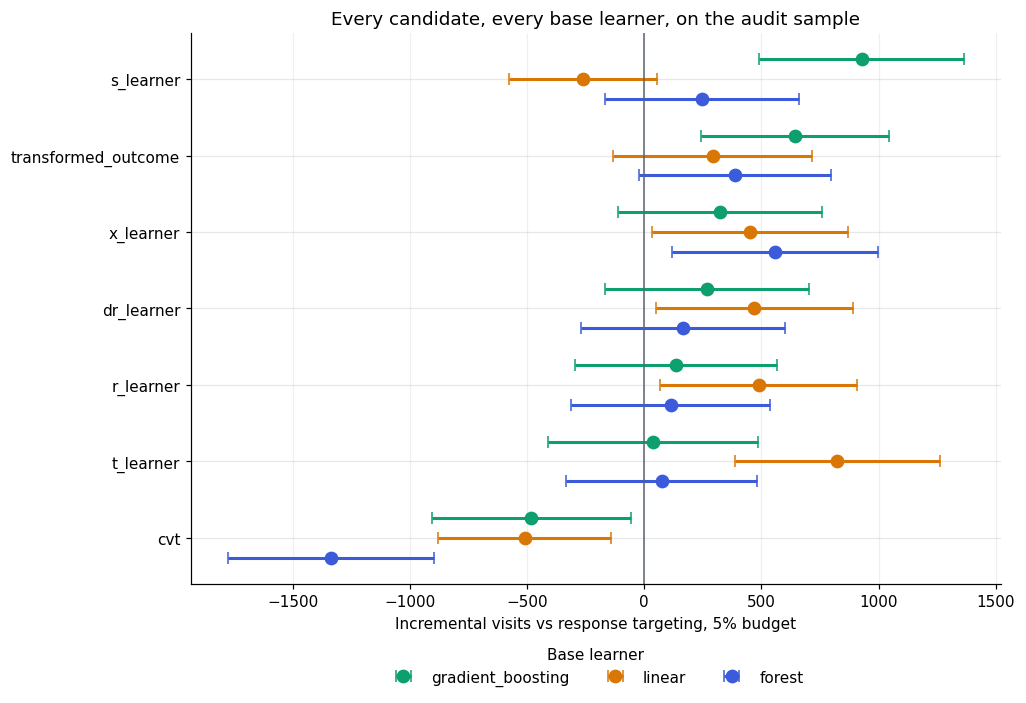

In [13]:
from src.reporting import BASE_FAMILY_COLORS

figure, axis = plt.subplots(figsize=(9.5, 6.5))
order = list(bounds.index)[::-1]
offsets = np.linspace(0.26, -0.26, len(families))

for family, offset in zip(families, offsets, strict=True):
    group = comparison[comparison["base_family"] == family].set_index("policy")
    group = group.loc[order]
    centre = group["difference"].to_numpy(dtype=float)
    low = group["ci_lower"].to_numpy(dtype=float)
    high = group["ci_upper"].to_numpy(dtype=float)
    axis.errorbar(
        centre,
        np.arange(len(order)) + offset,
        xerr=np.vstack([centre - low, high - centre]),
        marker="o",
        markersize=8,
        linestyle="none",
        linewidth=2,
        capsize=4,
        color=BASE_FAMILY_COLORS[family],
        label=family,
    )

axis.axvline(0.0, color="#5b6470", linewidth=1)
axis.set_yticks(range(len(order)))
axis.set_yticklabels(order)
axis.set_ylim(-0.6, len(order) - 0.4)
axis.set_xlabel("Incremental visits vs response targeting, 5% budget")
axis.set_title("Every candidate, every base learner, on the audit sample")
axis.grid(alpha=0.2, axis="x")
axis.legend(title="Base learner", loc="upper center",
            bbox_to_anchor=(0.5, -0.09), ncol=len(families), frameon=False)
plt.show()

## 7. A determinism wrinkle the forest introduces

`docs/determinism.md` records that LightGBM predictions came out bit-identical
across thread counts on the machine that produced the published tables. That is
a measurement rather than a guarantee, and it is a close call: LightGBM only
promises stable sums under `deterministic=true`, which this project does not
set. The forest is not a close call. It drifts by construction.

scikit-learn's forests average their trees by accumulating predictions into a
shared array as worker threads finish. Floating point addition is not
associative, so the same fitted forest can return slightly different predictions
from two identical calls.

The cell below isolates the smallest version of the effect: one fitted forest,
scored twice. At full scale the forest is also *refit* on each fold, and the
drift compounds - three independent runs of the comparison script moved the
forest column by up to 37.8 incremental outcomes, against a selection
half-width near 441. `docs/determinism.md` records that measurement. All
twenty-one ranks were identical in all three runs, which is the same point the
cell after next makes at this smaller scale.

In [14]:
scoring_rows = 120_000
score_data = subsample_criteo(
    load_criteo(AUDIT_SAMPLE, outcome="visit"), scoring_rows, SEED
)
fit_end = scoring_rows // 2

forest_s_learner = SLearner(base_family="forest").fit(
    score_data.X.iloc[:fit_end],
    score_data.y.iloc[:fit_end],
    score_data.treatment.iloc[:fit_end],
    random_state=SEED,
)
held_out = score_data.X.iloc[fit_end:]

first = forest_s_learner.predict_uplift(held_out)
second = forest_s_learner.predict_uplift(held_out)

print(f"scored users                    : {len(held_out):,}")
print(f"two calls give identical scores : {np.array_equal(first, second)}")
print(f"largest disagreement            : {np.abs(first - second).max():.3g}")
print(f"typical uplift score            : {np.abs(first).mean():.3g}")

scored users                    : 60,000
two calls give identical scores : False
largest disagreement            : 5.55e-16
typical uplift score            : 0.00267


The scores are not bit-identical. The number that matters, though, is not
whether the scores move but whether the *decision* moves: the policy targets the
top slice by rank, so a wobble far below the gap between neighbouring users
changes nobody's treatment.

In [15]:
budget_size = int(round(0.05 * len(held_out)))
top_first = set(np.argsort(-first, kind="stable")[:budget_size])
top_second = set(np.argsort(-second, kind="stable")[:budget_size])
swapped = len(top_first ^ top_second)

print(f"users targeted at a 5% budget      : {budget_size:,}")
print(f"users in one list but not the other: {swapped}")
print(f"share of the targeted list         : {swapped / budget_size:.4%}")

users targeted at a 5% budget      : 3,000
users in one list but not the other: 0
share of the targeted list         : 0.0000%


## 8. A cross-check the tables have to pass

The transformed-outcome learner defaults to ridge, and ridge is exactly what the
linear family's regressor is. So that one candidate should be *identical* in the
locked configuration and in the linear column, while every other candidate
differs. If it is not identical, the family plumbing is changing something it
was not supposed to touch.

This is checkable against a file written before families existed. The locked
selection table stores policy values against no treatment, so the contrast
against response targeting has to be recovered by subtraction before the two can
be compared.

In [16]:
locked = pd.read_csv(
    OUTPUTS / "tables/audit_visit_selection.csv", encoding="utf-8-sig"
)
locked_at_budget = locked[np.isclose(locked["budget_pct"], BUDGET_PCT)]
locked_at_budget = locked_at_budget.set_index("policy")["incremental_outcome"]
locked_contrast = locked_at_budget - locked_at_budget["response_model"]

check = comparison.set_index(["base_family", "policy"])["difference"]
rows = []
for policy in bounds.index:
    rows.append(
        {
            "policy": policy,
            "locked (ridge for transformed_outcome)": locked_contrast[policy],
            "linear column": check[("linear", policy)],
            "identical": bool(
                np.isclose(
                    locked_contrast[policy],
                    check[("linear", policy)],
                    rtol=0.0,
                    atol=1e-9,
                )
            ),
        }
    )
pd.DataFrame(rows)

,policy,locked (ridge for transformed_outcome),linear column,identical
0,s_learner,927.967129,-262.941765,False
1,transformed_outcome,291.572450,291.572450,True
2,x_learner,322.863520,450.609625,False
3,dr_learner,267.627894,468.664562,False
4,r_learner,136.775154,487.638328,False
5,t_learner,38.864917,824.548345,False
6,cvt,-482.179078,-509.357138,False


Exactly one row matches, and it is the row that was predicted to match. That is
the plumbing behaving: the linear family reaches only the six candidates whose
estimator it actually changes, and leaves the seventh alone because it was
already using that estimator.

## 9. What this changes, and what it does not

**What this does not change.**

No number in `outputs/` moves, and the locked policy is exactly what it was. The
confirmatory result was never a claim about which learner is best: it is a
measurement of one specific policy, an S-learner on boosted trees, taken once on
four million rows nothing else had touched. That measurement stands.

The claim about the policy *class* survives too. In every family at least one
uplift candidate finishes with a lower bound above zero against response
targeting. Which candidate manages it changes; that one does, does not.

**What this does change.**

"The S-learner is the best of the seven" was never a supported claim, and it is
now visibly unsupported. Given linear estimators it finishes sixth of seven. The
README's observation that the S-learner never leaves the top two is a statement
about ten data splits at one fixed estimator, and has to be read as exactly
that.

**The one ranking that holds.**

`cvt` finishes last in all three families. It is the only candidate whose rank
does not move, and the stable finding is a negative one: whatever estimator it
is handed, the class-variable transformation is the worst of these seven here.

**Why this is not a crisis.**

In all three families the gap between first and second place is smaller than the
half-width of first place's own interval. No column separates its winner from
its runner-up, so the reordering between columns is movement inside the noise
rather than evidence that a particular estimator suits a particular recipe.

That is the same conclusion the stability experiment reached along the data
axis, reached again along the estimator axis. Two independent routes to "the
selection rule can rank these candidates but cannot separate them" is a stronger
result than one route, and it is what the README already claims. This notebook
is the evidence for it rather than a correction to it.

In [17]:
print("gap between first and second, against first place's own half-width")
print()
for row in closeness.itertuples(index=False):
    verdict = "cannot separate" if row.margin_over_halfwidth < 1 else "separates"
    print(
        f"{row.base_family:>18}: champion {row.champion:<20}"
        f" ratio {row.margin_over_halfwidth:.2f}  ({verdict})"
    )

gap between first and second, against first place's own half-width

 gradient_boosting: champion s_learner            ratio 0.57  (cannot separate)
            linear: champion t_learner            ratio 0.73  (cannot separate)
            forest: champion x_learner            ratio 0.31  (cannot separate)
